In [1]:
from math import *
import numpy as np
import matplotlib.pyplot as plt

import scipy.constants as sc
mec2 = sc.m_e*sc.c**2 / sc.e

# Lienard-Wiechert fields of moving charge

the source particle moves along z passing z=0 at t=0.<br>
$\vec \beta$ and the observation direction $\vec n$ point in positive z direction.<br>
We compute the fields around the particle at t=0, so, for positive z values the particle position at negative times is relevant (due to the retardation). If we assume the particle to move with velocity $\beta$ a signal emitted at $t_0 = \frac{-z}{(1-\beta)c}$ at $z_0 = -z \frac{\beta}{1-\beta}$ arrives at time t=0 arrives at position $z$. The observation distance is $R\, =\, z-z_0\, =\, z\frac{1}{1-\beta} \approx 2\gamma^2\,z$

$\beta \, c \, t_0 = z0$<br>
$c \, t_0 = z_0 \, - \, z$

$(1-\beta) \, c \, t_0 = -z$

$t_0 = \frac{(-z)}{(1-\beta) \, c}$<br>
$z_0 = (-z) \, \frac{\beta}{1-\beta}$

We first consider the "acceleration" term with $\dot{\vec \beta} = \beta \vec{e_x}$:

$E(t,z) = \frac{e}{c} \left[ \frac{{\vec n}\times\left( ({\vec n}-{\vec \beta}) \times \dot{\vec \beta} \right)}
{(1-{\vec \beta}{\vec n})^3 \; R} \right]_{ret}\;$

In [32]:
γ = 50
β = sqrt(1.0-1/γ**2)
print(β)

e_x = np.array([1.0, 0.0, 0.0])
e_z = np.array([0.0, 0.0, 1.0])
n_Vec = e_z
β_Vec = β * e_z

def retR(z):
    return z/(1.0-β)
    
def LW_acc(z, β_prime):
    v1 = n_Vec - β_Vec
    βp_Vec = β_prime * e_x
    v2 = np.cross(n_Vec - β_Vec, βp_Vec)
    v3 = np.cross(n_Vec, v2)
    denominator = (1.0-np.dot(n_Vec,β_Vec))**3 * retR(z)
    return 1.0/sc.c * np.dot(v3,e_x)/denominator

0.999799979995999


In [33]:
LW_acc(0.001, 1.0)

-0.016676536772617125

Approximating $\beta = \sqrt{1-1/\gamma^2}$  as $1-\frac{1}{2\gamma^2}$ one obtains:<br>
$E(t,z) \approx \frac{e}{c} \; \frac{4\,\gamma^4}{R} \dot\beta \; \approx\;  2\gamma^2 \; \frac{\dot\beta}{z}$

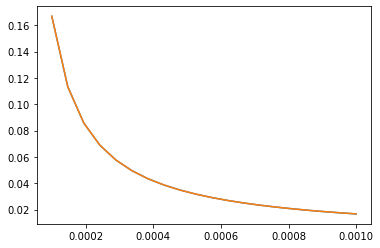

In [42]:
z_List = np.linspace(1e-4,0.001,20)
Ex_List = [LW_acc(z, -1.0) for z in z_List]
Ana_List = [1.0/sc.c*2*γ**2/z for z in z_List]
plt.plot(z_List,Ex_List)
plt.plot(z_List,Ana_List)
plt.show()

In [ ]:
z_List = np.linspace(1e-4,0.001,20)
Ex_List = [LW_acc(z, -1.0) for z in z_List]
Ana_List = [1.0/sc.c*2*γ**2/z for z in z_List]
plt.plot(z_List,Ex_List)
plt.plot(z_List,Ana_List)
plt.show()